In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import torch
import argparse
import yaml
from numba import cuda
import zuko
from sklearn.preprocessing import StandardScaler
from helpers.models.DNN import count_parameters
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples

plt.style.use("../science.mplstyle")


In [2]:
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d

In [3]:


BIN_BOUND = 5
NUM_BINS = 100
NUM_FEATURES = 5

parser = argparse.ArgumentParser()
parser.add_argument("--ZUKO_ID", type=str, default="NSF", help="Zuko model ID")
parser.add_argument("--SEED", type=int, default=8, help="Random seed")
parser.add_argument("--NUM_EPOCHS", type=int, default=5, help="Number of training epochs")
parser.add_argument("--LEARNING_RATE", type=float, default=1e-3, help="Learning rate")
parser.add_argument("--BATCH_SIZE", type=int, default=512, help="Batch size")
parser.add_argument("--NUM_COND_INPUTS", type=int, default=0, help="Number of conditional inputs")
parser.add_argument("--PLOT_EPOCH_INTERVAL", type=int, default=5, help="Interval for plotting during training")
args = parser.parse_args([])

In [4]:
save_dir = f"outputs/{args.ZUKO_ID}"
os.makedirs(save_dir, exist_ok=True)

In [5]:

# computing
device = cuda.get_current_device()
device.reset()
torch.set_num_threads(2)
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)
seed = int(args.SEED)
torch.manual_seed(seed)
np.random.seed(seed)

Using device: cuda


In [6]:
collections_TrackerHitPlane = [
    "IBTrackerHits",
    "IBTrackerHitsConed",
    "IETrackerHits", 
    "IETrackerHitsConed",
    "OBTrackerHits",
    "OBTrackerHitsConed", 
    "OETrackerHits",        
    "OETrackerHitsConed",          
    "VBTrackerHits",               
    "VBTrackerHitsConed",   
    "VETrackerHits",  
    "VETrackerHitsConed",        
]

collections_SimTrackerHit = [
  #  "InnerTrackerBarrelCollection",
   # "InnerTrackerBarrelCollectionConed",
 #   "InnerTrackerEndcapCollection",
    #"InnerTrackerEndcapCollectionConed", 
    "OuterTrackerBarrelCollection",     
   # "OuterTrackerBarrelCollectionConed",
 #   "OuterTrackerEndcapCollection",  
   # "OuterTrackerEndcapCollectionConed",
 #   "VertexBarrelCollection",   
   # "VertexBarrelCollectionConed",   
  #  "VertexEndcapCollection",
   # "VertexEndcapCollectionConed",
]



feature_labels = ["log($E$) [Gev]", "$x$", "$y$", "$z$", "$t$ [s]", "context"]
log_vars = []

In [7]:

data = []
context = []

for i, collection in enumerate(collections_SimTrackerHit): # TODO coned too?

    tmp_data = np.load(f"/pscratch/sd/r/rmastand/muon/npys/{collection}_SimTrackerHit.npy")
    tmp_context = int(i)*np.ones((tmp_data.shape[0],1))
    context.append(tmp_context)
    data.append(tmp_data[:int(len(tmp_data)*.1)])


data = np.vstack(data)[:,[0,2,3,4,5]]
#data = data[data[:,0] > 2e-6]
data[:,0] = np.log(data[:,0])
context = np.vstack(context)

bins_dict = {}
bins_dict_preproc = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(data.shape[1])}

for i in range(data.shape[1]):
    if i in log_vars:
        bins_dict[i] = np.logspace(np.log10(0.9*np.min(data[:,i])), np.log10(1.1*np.max(data[:,i])), NUM_BINS) 
    else:
        bins_dict[i] = np.linspace(np.min(data[:,i] - 3), np.max(data[:,i] + 3), NUM_BINS) 

In [8]:

def preprocess_data(X, flow_training_dir):
    """
    Preprocess data without modifying the original array.
    Applies log to the first column and standardizes all columns.
    """
    
    # standardize all columns
    standard_scaler = StandardScaler()
    X_preproc = standard_scaler.fit_transform(X)

    # save scaler for inverse transform
    with open(f"{flow_training_dir}/standard", "wb") as ofile:
        pickle.dump(standard_scaler, ofile)

    return X_preproc


def inverse_preprocess_data(X_preproc, flow_training_dir,):
    """
    Inverse preprocessing without modifying the input array.
    Inverts standardization and applies exp to the first column.
    """
    # load scaler
    with open(f"{flow_training_dir}/standard", "rb") as ifile:
        standard_scaler = pickle.load(ifile)

    # inverse standardization
    X = standard_scaler.inverse_transform(X_preproc)

    return X

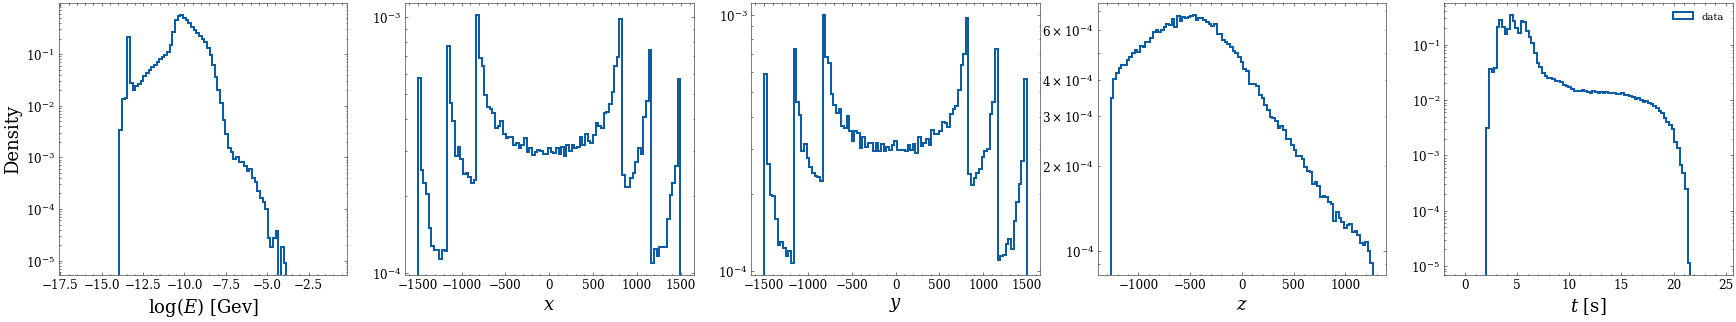

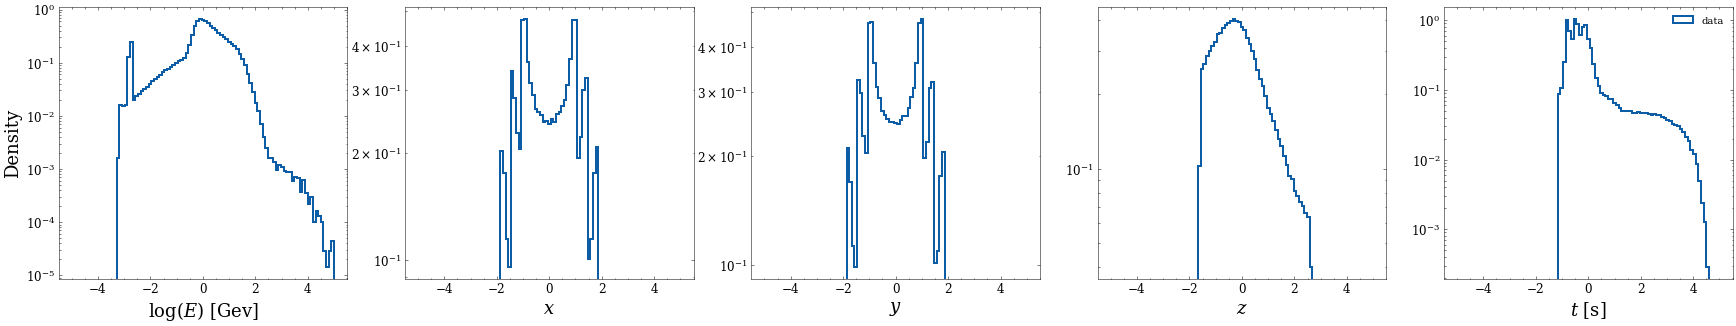

In [9]:


X_preproc = preprocess_data(data, ".")
if args.NUM_COND_INPUTS == 1:
    X_preproc = np.hstack([X_preproc,  context])
elif args.NUM_COND_INPUTS == 0:
    pass
else:
    print("ERROR")
    exit()


plot_hists_1d({"data":data}, bins_dict, log_dims=log_vars, labels=feature_labels)
plt.show()

plot_hists_1d({"data":X_preproc}, bins_dict_preproc, log_dims=[], labels = feature_labels)
plt.show()

In [ ]:
# train val split
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(X_preproc, test_size=0.2, random_state=42)

print(f"Train data has shape {data_train.shape}.")
print(f"Val data has shape {data_val.shape}.")


train_loader = torch.utils.data.DataLoader(data_train, batch_size=args.BATCH_SIZE, shuffle=True, num_workers = 8, pin_memory = True)
val_loader = torch.utils.data.DataLoader(data_val, batch_size=args.BATCH_SIZE, shuffle=False, num_workers = 8, pin_memory = True)

In [ ]:
import zuko

# Neural spline flow (NSF) with 3 sample features and 5 context features

if args.ZUKO_ID == "NSF":
    flow = zuko.flows.NSF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
#elif args.ZUKO_ID == "GMM":
#    flow = zuko.flows.GMM(5, 0, components=30, hidden_features=[256] * 5).to(device)
elif args.ZUKO_ID == "NICE":
    flow = zuko.flows.NICE(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif args.ZUKO_ID == "MAF":
    flow = zuko.flows.MAF(5, 0, transforms=5, hidden_features=[256] * 3).to(device)
elif args.ZUKO_ID == "NCSF":
    flow = zuko.flows.NCSF(5, 0, transforms=3, hidden_features=[128] * 3, bins=16).to(device)
elif args.ZUKO_ID == "SOSPF":
    flow = zuko.flows.SOSPF(5, 0, transforms=3, hidden_features=[128] * 3, degree=4, polynomials=3).to(device)
elif args.ZUKO_ID == "NAF":
    flow = zuko.flows.NAF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif args.ZUKO_ID == "UNAF":
    flow = zuko.flows.UNAF(5, 0, transforms=3, hidden_features=[128] * 3).to(device)
elif args.ZUKO_ID == "CNF":
    flow = zuko.flows.CNF(5, 0, hidden_features=[256] * 3).to(device)
elif args.ZUKO_ID == "GF":
    flow = zuko.flows.GF(5, 0, transforms=7, hidden_features=[256] * 5, components=8).to(device)
elif args.ZUKO_ID == "BPF":
    flow = zuko.flows.BPF(5, 0, transforms=5, hidden_features=[256] * 3, degree=16).to(device)
else:
    print("ERROR: Unknown ZUKO_ID")
    exit()


num_params = count_parameters(flow)
print(f"Number of trainable parameters: {num_params}")
with open(f"{save_dir}/num_params.txt", "w") as ofile:
    ofile.write(f"Number of trainable parameters: {num_params}")

# Train to maximize the log-likelihood
optimizer = torch.optim.Adam(flow.parameters(), lr=args.LEARNING_RATE)

In [ ]:
losses_train, losses_val = [], []
best_val_loss = 1e10
        

for k in range(args.NUM_EPOCHS):

    epoch_losses_train, epoch_losses_val = [], []

    # TRAINING LOOP
    pbar = tqdm(train_loader, desc="Train batches", leave=False, )
    for x in pbar:
        optimizer.zero_grad()

        x = x.to(device).float()

        loss = -flow().log_prob(x).mean()

        epoch_losses_train.append(loss.item())
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=f"{loss.item():.3e}, epoch {k}")

    losses_train.append(np.mean(epoch_losses_train))

    # VALIDATION LOOP
    pbar = tqdm(val_loader, desc="Val batches", leave=False, )
    for x in pbar:

        x = x.to(device).float()
        with torch.no_grad():
            loss = -flow().log_prob(x).mean()
    
        epoch_losses_val.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.3e}, epoch {k}")

    losses_val.append(np.mean(epoch_losses_val))

    if losses_val[-1] < best_val_loss:
        best_val_loss = losses_val[-1]
        #print("new best val loss", losses_val[-1])
        
        torch.save(flow.state_dict(), f"{save_dir}/test.pt")

    if (k + 1) % args.PLOT_EPOCH_INTERVAL == 0:
       
        plt.figure()
        plt.plot(losses_train, label="train")
        plt.plot(losses_val, label="val")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"{save_dir}/losses")

        
        samples = flow().sample((10000,)).detach().cpu().numpy()
            
        loc_data_dict = {"data": inverse_preprocess_data( data_val , "."),
                "generated": inverse_preprocess_data( samples , ".")}
        plot_hists_1d(loc_data_dict, bins_dict, log_dims=log_vars)
        plt.savefig(f"{save_dir}/hists")

        for key in loc_data_dict.keys():
            fig_samp, axes_samp = plot_corner_hist_2d(
                loc_data_dict[key],
                feature_labels=[f"feature {i}" for i in range(NUM_FEATURES)],
                bins_dict=bins_dict,
                log_dims=log_vars,
                title= key,
            )
            plt.savefig(f"{save_dir}/corner_{key}")



In [ ]:


print("Making flow samples...")

eval_flow = flow

# get epoch of best val loss
#best_epoch = np.nanargmin(val_losses) - 1
#model_path = f"{flow_training_dir}/flow_epoch_{best_epoch}.par"

#eval_model = DensityEstimator(path_to_config_file, NUM_FEATURES, NUM_COND_INPUTS,
#                         eval_mode=True,
#                         load_path=model_path,
#                         device=device, verbose=False,
#                         bound=False)


num_samples_total = data.shape[0] 
sample_batch_size = 8192

samples_flow = []
for i in tqdm(range(0, num_samples_total, sample_batch_size)):
    if i + sample_batch_size > num_samples_total:
        nn = num_samples_total - i
    else:
        nn = sample_batch_size
    loc_samples = eval_flow().sample((nn,)).detach().cpu().numpy()
    samples_flow.append(loc_samples)
samples_flow = np.concatenate(samples_flow)

X_samples = {
        "flow_samples":samples_flow
    }



In [ ]:
for key in X_samples.keys():
    
    X_samples[key] = inverse_preprocess_data( X_samples[key] , ".")

In [ ]:

plot_hists_1d({"data":data, **X_samples}, bins_dict, log_dims=log_vars)
plt.savefig(f"{save_dir}/hists_final")

In [ ]:
for key in X_samples.keys():
    fig_samp, axes_samp = plot_corner_hist_2d(
        X_samples[key],
        feature_labels=[f"feature {i}" for i in range(NUM_FEATURES)],
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= key,
    )
    plt.savefig(f"{save_dir}/corner_{key}_final")



# Train a BDT to discriminate flow from samples

In [ ]:

for key in X_samples.keys():
    with open(f"{save_dir}/results.txt", "w") as ofile:
        ks_dists_samples = get_kl_dist(data, X_samples[key])
        ks_dists_gaussians = get_kl_dist(np.random.normal(size = data.shape), np.random.normal(size =  X_samples[key].shape))
        
                                                
        for i, ks_dist in enumerate(ks_dists_samples):
            ofile.write("Feature {i} KL div: {ks_dist} (for gaussian: {ks_gauss})".format(i=i, ks_dist=ks_dist, ks_gauss=ks_dists_gaussians[i]))
            ofile.write("\n")
        
        auc_mean, auc_std, best_epoch, max_epochs = discriminate_data_from_samples(data,  X_samples[key], n_runs=5, bdt_config="configs/bdt.yml")
        ofile.write(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch} of {max_epochs}.\n")